# 01 - Análisis exploratorio (EDA) de la serie horaria de ozono troposférico (O3)

En este notebook, se realiza el análisis exploratorio inicial de la serie de ozono troposférico (O3) registrada por la estación del Eixample (para el periodo 2020-2025).

Los objetivos principales de la EDA son los siguientes:

1. Realizar la carga del conjunto bruto de datos.
2. Inspeccionar la estructura de este.
3. Convertir el formato diario ancho, (esto es, con columnas `h01`-`h24`), en una serie temporal horaria.
4. Evaluar la calidad de los datos: rango temporal, duplicados, valores ausentes y continuidad.
5. Generar las primeras tablas y figuras que servirán para la memoria.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

# Se amplía el número de columnas visibles para inspeccionar mejor el dataset.
pd.set_option("display.max_columns", 100)

# Se evita que pandas corte demasiado pronto el contenido de algunas salidas.
pd.set_option("display.max_rows", 100)

In [ ]:
def find_project_root(start: Path | None = None) -> Path:
    """Busca la raíz del proyecto partiendo del directorio actual.

    Esta función evita depender de rutas absolutas locales. Así, el notebook puede
    ejecutarse aunque el repositorio esté guardado en otra carpeta o se abra desde
    un directorio diferente dentro del proyecto.
    """
    start = Path.cwd() if start is None else start

    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "src").exists():
            return candidate

    raise FileNotFoundError("No se ha podido localizar la raíz del proyecto.")


# Se localiza automáticamente la carpeta raíz del repositorio.
PROJECT_ROOT = find_project_root()

# Ruta del conjunto de datos bruto.
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "Eixample_O3_2020_2025.csv"

# Carpetas donde se guardarán las tablas y figuras generadas durante la EDA.
TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
FIGURES_GENERATED_DIR = PROJECT_ROOT / "reports" / "figures" / "generated"

# Se comprueba que las carpetas de salida existen antes de guardar resultados.
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_GENERATED_DIR.mkdir(parents=True, exist_ok=True)

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Archivo bruto: {RAW_DATA_PATH}")

Raíz del proyecto: c:\trabajo_github
Archivo bruto: c:\trabajo_github\data\raw\Eixample_O3_2020_2025.csv


In [ ]:
# Se carga el conjunto de datos bruto sin aplicar, todavía, ninguna transformación.
# En esta fase inicial se comprobará su tamaño, estructura y se obtendrá una muestra de sus primeras filas.
raw_df = pd.read_csv(RAW_DATA_PATH)

print(f"Filas: {raw_df.shape[0]:,}")
print(f"Columnas: {raw_df.shape[1]:,}")

display(raw_df.head())
display(raw_df.tail())

Filas: 2,192
Columnas: 40


,codi_eoi,nom_estacio,data,magnitud,contaminant,unitats,tipus_estacio,area_urbana,codi_ine,municipi,codi_comarca,nom_comarca,h01,h02,h03,h04,h05,h06,h07,h08,h09,h10,h11,h12,h13,h14,h15,h16,h17,h18,h19,h20,h21,h22,h23,h24,altitud,latitud,longitud,geocoded_column
0,8019043,Barcelona (Eixample),2025-12-31T00:00:00.000,14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,12.0,34.0,28.0,29.0,22.0,26.0,31.0,29.0,26.0,23.0,28.0,30.0,39.0,43.0,35.0,36.0,24.0,23.0,29.0,25.0,32.0,36.0,39.0,42.0,26,41.385315,2.1538,NaN
1,8019043,Barcelona (Eixample),2025-12-30T00:00:00.000,14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,10.0,21.0,28.0,27.0,29.0,37.0,39.0,30.0,33.0,36.0,36.0,34.0,30.0,29.0,35.0,39.0,34.0,34.0,37.0,37.0,27.0,6.0,4.0,14.0,26,41.385315,2.1538,NaN
2,8019043,Barcelona (Eixample),2025-12-29T00:00:00.000,14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,28.0,35.0,36.0,45.0,54.0,53.0,42.0,16.0,15.0,NaN,NaN,NaN,29.0,30.0,46.0,46.0,34.0,26.0,19.0,5.0,3.0,3.0,3.0,3.0,26,41.385315,2.1538,NaN
3,8019043,Barcelona (Eixample),2025-12-28T00:00:00.000,14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,64.0,64.0,53.0,61.0,50.0,54.0,51.0,46.0,40.0,41.0,51.0,65.0,71.0,77.0,73.0,71.0,70.0,68.0,60.0,41.0,27.0,30.0,32.0,33.0,26,41.385315,2.1538,NaN
4,8019043,Barcelona (Eixample),2025-12-27T00:00:00.000,14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,67.0,67.0,74.0,75.0,74.0,63.0,73.0,76.0,77.0,80.0,72.0,58.0,73.0,67.0,70.0,73.0,73.0,75.0,72.0,66.0,68.0,73.0,71.0,69.0,26,41.385315,2.1538,NaN


,codi_eoi,nom_estacio,data,magnitud,contaminant,unitats,tipus_estacio,area_urbana,codi_ine,municipi,codi_comarca,nom_comarca,h01,h02,h03,h04,h05,h06,h07,h08,h09,h10,h11,h12,h13,h14,h15,h16,h17,h18,h19,h20,h21,h22,h23,h24,altitud,latitud,longitud,geocoded_column
2187,8019043,Barcelona (Eixample),2020-01-05T00:00:00.000,14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,31.0,15.0,19.0,31.0,29.0,24.0,22.0,19.0,8.0,11.0,8.0,8.0,10.0,4.0,12.0,33.0,29.0,22.0,9.0,1.0,1.0,1.0,2.0,3.0,26,41.385315,2.1538,POINT (2.1537998 41.385315)
2188,8019043,Barcelona (Eixample),2020-01-04T00:00:00.000,14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0,5.0,11.0,14.0,28.0,28.0,19.0,23.0,27.0,25.0,22.0,26.0,8.0,15.0,26,41.385315,2.1538,POINT (2.1537998 41.385315)
2189,8019043,Barcelona (Eixample),2020-01-03T00:00:00.000,14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,1.0,17.0,35.0,33.0,25.0,28.0,17.0,11.0,9.0,10.0,7.0,11.0,11.0,11.0,10.0,6.0,4.0,2.0,1.0,1.0,1.0,1.0,2.0,1.0,26,41.385315,2.1538,POINT (2.1537998 41.385315)
2190,8019043,Barcelona (Eixample),2020-01-02T00:00:00.000,14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,4.0,5.0,5.0,4.0,1.0,1.0,2.0,1.0,2.0,4.0,9.0,22.0,31.0,33.0,33.0,34.0,37.0,22.0,2.0,2.0,2.0,5.0,9.0,1.0,26,41.385315,2.1538,POINT (2.1537998 41.385315)
2191,8019043,Barcelona (Eixample),2020-01-01T00:00:00.000,14,O3,µg/m3,traffic,urban,8019,Barcelona,13,Barcelonès,22.0,19.0,19.0,6.0,8.0,5.0,4.0,2.0,2.0,8.0,13.0,25.0,27.0,19.0,22.0,25.0,26.0,18.0,16.0,15.0,13.0,11.0,3.0,1.0,26,41.385315,2.1538,POINT (2.1537998 41.385315)


In [ ]:
# Las columnas h01-h24 contienen las mediciones horarias correspondientes a cada día.
hour_columns = [f"h{hour:02d}" for hour in range(1, 25)]

# El resto de las columnas se considerarán como metadatos, a saber: estación, fecha, contaminante, ubicación, etc.
metadata_columns = [column for column in raw_df.columns if column not in hour_columns]

# Se verifica que todas las columnas horarias esperadas estén presentes.
missing_hour_columns = [column for column in hour_columns if column not in raw_df.columns]

if missing_hour_columns:
    raise ValueError(f"Faltan columnas horarias esperadas: {missing_hour_columns}")

print("Columnas horarias:")
print(hour_columns)

print("\nColumnas de metadatos:")
print(metadata_columns)

# Se muestran algunas columnas clave que permitirán confirmar la estación, la fecha, el contaminante y las unidades.
display(raw_df[["nom_estacio", "data", "contaminant", "unitats"]].head())

Columnas horarias:
['h01', 'h02', 'h03', 'h04', 'h05', 'h06', 'h07', 'h08', 'h09', 'h10', 'h11', 'h12', 'h13', 'h14', 'h15', 'h16', 'h17', 'h18', 'h19', 'h20', 'h21', 'h22', 'h23', 'h24']

Columnas de metadatos:
['codi_eoi', 'nom_estacio', 'data', 'magnitud', 'contaminant', 'unitats', 'tipus_estacio', 'area_urbana', 'codi_ine', 'municipi', 'codi_comarca', 'nom_comarca', 'altitud', 'latitud', 'longitud', 'geocoded_column']


,nom_estacio,data,contaminant,unitats
0,Barcelona (Eixample),2025-12-31T00:00:00.000,O3,µg/m3
1,Barcelona (Eixample),2025-12-30T00:00:00.000,O3,µg/m3
2,Barcelona (Eixample),2025-12-29T00:00:00.000,O3,µg/m3
3,Barcelona (Eixample),2025-12-28T00:00:00.000,O3,µg/m3
4,Barcelona (Eixample),2025-12-27T00:00:00.000,O3,µg/m3


In [ ]:
def convert_daily_wide_to_hourly(raw_data: pd.DataFrame) -> pd.DataFrame:
    """Convierte el formato diario ancho h01-h24 a una serie temporal horaria.

    Es decir: se interpreta que la columna `h01` se corresponde con la primera hora del día y `h24` con la última.
    Así pues, se asignará h01` a las 00:00, `h02` a las 01:00, etc.
    De esta forma y siguiendo esta convención, se construirá una serie horaria regular.

    La serie resultante será la base para la EDA, la creación de retardos y el entrenamiento posterior de los modelos.
    """
    data = raw_data.copy()

    # La columna "data" representa el día de observación.
    data["date"] = pd.to_datetime(data["data"]).dt.normalize()

    # Se pasa de 24 columnas horarias a una fila por hora.
    long_data = data.melt(
        id_vars=[column for column in data.columns if column not in hour_columns],
        value_vars=hour_columns,
        var_name="hour_label",
        value_name="o3",
    )

    # Como se mencionó, h01 se transforma en la hora 00:00, h02 en la hora 01:00, etc.
    long_data["hour"] = long_data["hour_label"].str.replace("h", "").astype(int) - 1

    # Se construye la marca temporal horaria a partir del día y la hora.
    long_data["timestamp"] = long_data["date"] + pd.to_timedelta(long_data["hour"], unit="h")

    # Se transforma la concentración de O3 a formato numérico.
    # Los valores que no se puedan convertir se transforman en NaN.
    long_data["o3"] = pd.to_numeric(long_data["o3"], errors="coerce")

    hourly_data = long_data[
        ["timestamp", "o3", "nom_estacio", "contaminant", "unitats"]
    ].sort_values("timestamp")

    return hourly_data.reset_index(drop=True)


hourly_df = convert_daily_wide_to_hourly(raw_df)

print(f"Filas horarias: {hourly_df.shape[0]:,}")
display(hourly_df.head())
display(hourly_df.tail())

Filas horarias: 52,608


,timestamp,o3,nom_estacio,contaminant,unitats
0,2020-01-01 00:00:00,22.0,Barcelona (Eixample),O3,µg/m3
1,2020-01-01 01:00:00,19.0,Barcelona (Eixample),O3,µg/m3
2,2020-01-01 02:00:00,19.0,Barcelona (Eixample),O3,µg/m3
3,2020-01-01 03:00:00,6.0,Barcelona (Eixample),O3,µg/m3
4,2020-01-01 04:00:00,8.0,Barcelona (Eixample),O3,µg/m3


,timestamp,o3,nom_estacio,contaminant,unitats
52603,2025-12-31 19:00:00,25.0,Barcelona (Eixample),O3,µg/m3
52604,2025-12-31 20:00:00,32.0,Barcelona (Eixample),O3,µg/m3
52605,2025-12-31 21:00:00,36.0,Barcelona (Eixample),O3,µg/m3
52606,2025-12-31 22:00:00,39.0,Barcelona (Eixample),O3,µg/m3
52607,2025-12-31 23:00:00,42.0,Barcelona (Eixample),O3,µg/m3


In [ ]:
# Se construye el índice horario que correspondería si la serie registrada fuera continua hora a hora
expected_index = pd.date_range(
    start=hourly_df["timestamp"].min(),
    end=hourly_df["timestamp"].max(),
    freq="h",
)

# Se comprueba si faltan timestamps en la secuencia temporal.
missing_timestamps = expected_index.difference(hourly_df["timestamp"])

# Se comprueba si existe más de una fila para la misma hora.
duplicated_timestamps = hourly_df["timestamp"].duplicated().sum()

# Se cuentan los valores ausentes de la variable objetivo O3.
missing_o3_values = hourly_df["o3"].isna().sum()

# Se efectúa un resumen básico del dataset en una tabla exportable.
quality_summary = pd.DataFrame(
    {
        "metric": [
            "start_timestamp",
            "end_timestamp",
            "expected_hourly_records",
            "actual_hourly_records",
            "missing_timestamps",
            "duplicated_timestamps",
            "missing_o3_values",
            "missing_o3_percentage",
            "min_o3",
            "max_o3",
            "mean_o3",
            "median_o3",
            "std_o3",
        ],
        "value": [
            hourly_df["timestamp"].min(),
            hourly_df["timestamp"].max(),
            len(expected_index),
            len(hourly_df),
            len(missing_timestamps),
            duplicated_timestamps,
            missing_o3_values,
            missing_o3_values / len(hourly_df) * 100,
            hourly_df["o3"].min(),
            hourly_df["o3"].max(),
            hourly_df["o3"].mean(),
            hourly_df["o3"].median(),
            hourly_df["o3"].std(),
        ],
    }
)

display(quality_summary)

# Se guarda la tabla para poder utilizarla en la memoria.
quality_summary.to_csv(TABLES_DIR / "eda_data_quality_summary.csv", index=False)

,metric,value
0,start_timestamp,2020-01-01 00:00:00
1,end_timestamp,2025-12-31 23:00:00
2,expected_hourly_records,52608
3,actual_hourly_records,52608
4,missing_timestamps,0
5,duplicated_timestamps,0
6,missing_o3_values,1666
7,missing_o3_percentage,3.166819
8,min_o3,1.0
9,max_o3,167.0


In [ ]:
# Se resume la serie anualmente para detectar las diferencias entre estos periodos.
# Esta tabla será útil para estudiar si, como consecuencia de la entrada en vigor
# de la ZBE y del impacto del COVID-19, 2020 presenta un comportamiento especial.
# También para comprobar la evolución de los valores ausentes, las medias y los valores extremos.
yearly_summary = (
    hourly_df.assign(year=hourly_df["timestamp"].dt.year)
    .groupby("year")
    .agg(
        records=("o3", "size"),
        missing_values=("o3", lambda values: values.isna().sum()),
        missing_percentage=("o3", lambda values: values.isna().mean() * 100),
        mean_o3=("o3", "mean"),
        median_o3=("o3", "median"),
        std_o3=("o3", "std"),
        min_o3=("o3", "min"),
        max_o3=("o3", "max"),
    )
)

display(yearly_summary)

# La tabla anual se guarda para documentar la calidad de los datos año a año.
yearly_summary.to_csv(TABLES_DIR / "eda_yearly_summary.csv")

,records,missing_values,missing_percentage,mean_o3,median_o3,std_o3,min_o3,max_o3
year,,,,,,,,
2020,8784,117,1.331967,40.113419,40.0,25.185510,1.0,115.0
2021,8760,282,3.219178,42.915782,45.0,23.078490,1.0,118.0
2022,8760,388,4.429224,42.470736,43.0,26.297803,1.0,141.0
2023,8760,153,1.746575,45.503311,47.0,23.782933,1.0,125.0
2024,8784,347,3.950364,48.548062,51.0,24.990742,1.0,120.0
2025,8760,379,4.326484,54.948574,56.0,27.985849,1.0,167.0


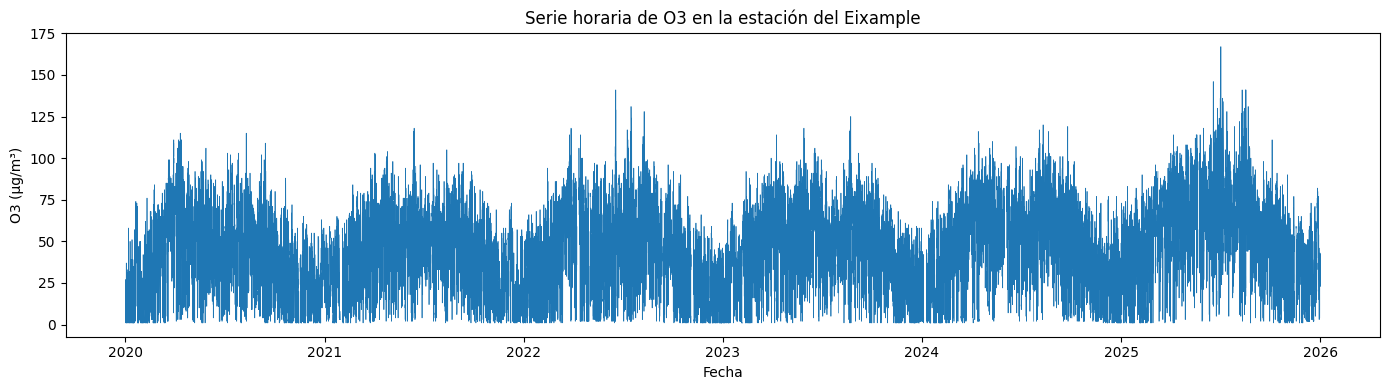

In [ ]:
# Esta es la primera visualización global de la serie.
# La figura permite detectar visualmente lapsos sin registros, valores extremos,
# cambios de nivel y patrones estacionales de largo plazo.
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(hourly_df["timestamp"], hourly_df["o3"], linewidth=0.5)

ax.set_title("Serie horaria de O3 en la estación del Eixample")
ax.set_xlabel("Fecha")
ax.set_ylabel("O3 (µg/m³)")

fig.tight_layout()

# La figura se guarda en /generated porque todavía cuenta con carácter exploratorio.
# Más adelante se guardarán las figuras finales en reports/figures/final/.
fig.savefig(
    FIGURES_GENERATED_DIR / "eda_o3_full_series.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()